In [10]:
import wradlib as wrl
import os
import matplotlib.pyplot as plt
# Set the WRADLIB_DATA environment variable
os.environ['WRADLIB_DATA'] = 'wradlib_data'

In [2]:
fpath = "scan-sidpol-120km-14_20001_20240814000001_00.h5"
f = wrl.util.get_wradlib_data_file(fpath)
data, metadata = wrl.io.read_gamic_hdf5(f)

In [4]:
print(data.keys())
print(data["SCAN0"].keys())
print(data["SCAN0"]["ZH"].keys())
print(data["SCAN0"]["ZH"]["data"])
print(data["SCAN0"]["ZH"]["data"].shape)

dict_keys(['SCAN0', 'SCAN1', 'SCAN10', 'SCAN11', 'SCAN12', 'SCAN13', 'SCAN2', 'SCAN3', 'SCAN4', 'SCAN5', 'SCAN6', 'SCAN7', 'SCAN8', 'SCAN9'])
dict_keys(['ZH', 'ZV', 'SQIH', 'CCORH', 'SNRH', 'UZH', 'UZV', 'ZDR', 'VH', 'WH', 'PHIDP', 'KDP', 'RHOHV'])
dict_keys(['data', 'dyn_range_max', 'dyn_range_min'])
[[96.00197  23.216534 96.00197  ... 31.75     30.746063 30.746063]
 [96.00197  26.730316 28.73819  ... 31.248032 34.259842 33.255905]
 [96.00197  96.00197  96.00197  ... 30.746063 31.75     32.753937]
 ...
 [96.00197  96.00197  96.00197  ... 30.244095 29.240158 31.248032]
 [96.00197  96.00197  96.00197  ... 32.753937 32.753937 31.248032]
 [96.00197  22.212597 96.00197  ... 34.259842 30.244095 32.25197 ]]
(361, 240)


## Data Cleaning

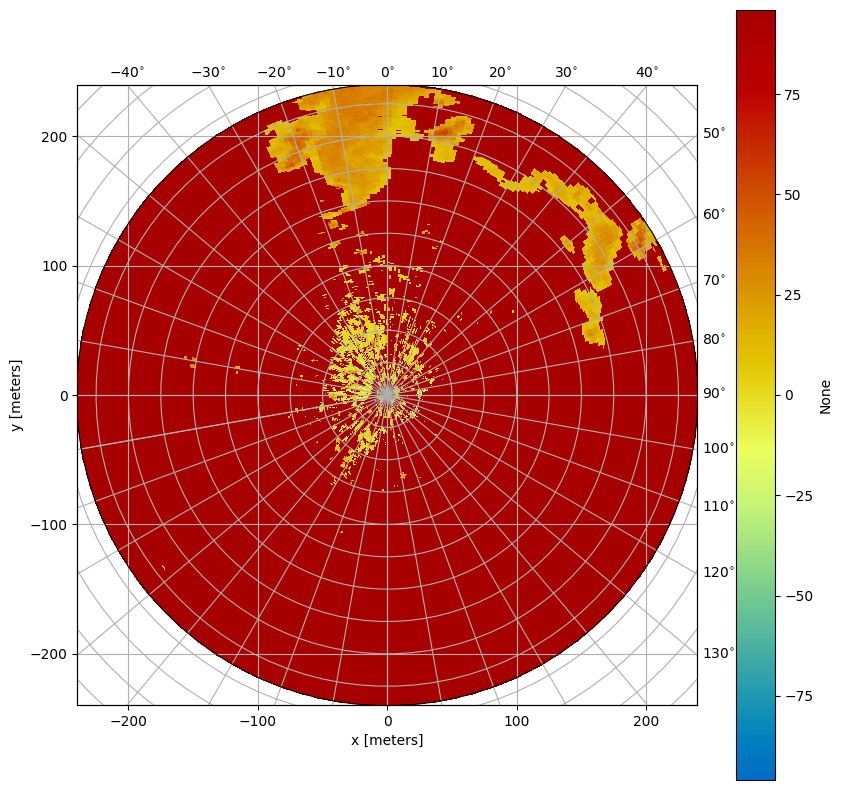

In [16]:
fig = plt.figure(figsize=(10, 10))
da = wrl.georef.create_xarray_dataarray(
    data["SCAN0"]["ZH"]["data"]
).wrl.georef.georeference()
im = da.wrl.vis.plot(fig=fig, crs="cg")

The 0 values are read as 96.00197 in this gamic reader so we need to fix this by changing these values to 0

In [ ]:
# Loop through all scans and set values of 96.00197 to 0
for scan_key in data.keys():
    if "ZH" in data[scan_key]:
        arr = data[scan_key]["ZH"]["data"]
        arr[arr == 96.00197] = 0
        data[scan_key]["ZH"]["data"] = arr 

In [23]:
print(data["SCAN13"]["ZH"]["data"])

[[ 16.690945 -14.933071 -20.454723 ...   0.         0.         0.      ]
 [  0.       -17.442913 -22.462599 ...   0.         0.         0.      ]
 [  0.       -19.952755 -27.482285 ...   0.         0.         0.      ]
 ...
 [  0.       -17.442913 -24.97244  ...   0.         0.         0.      ]
 [  0.       -16.438976 -19.952755 ...   0.         0.         0.      ]
 [  0.       -20.454723 -17.944881 ...   0.         0.         0.      ]]


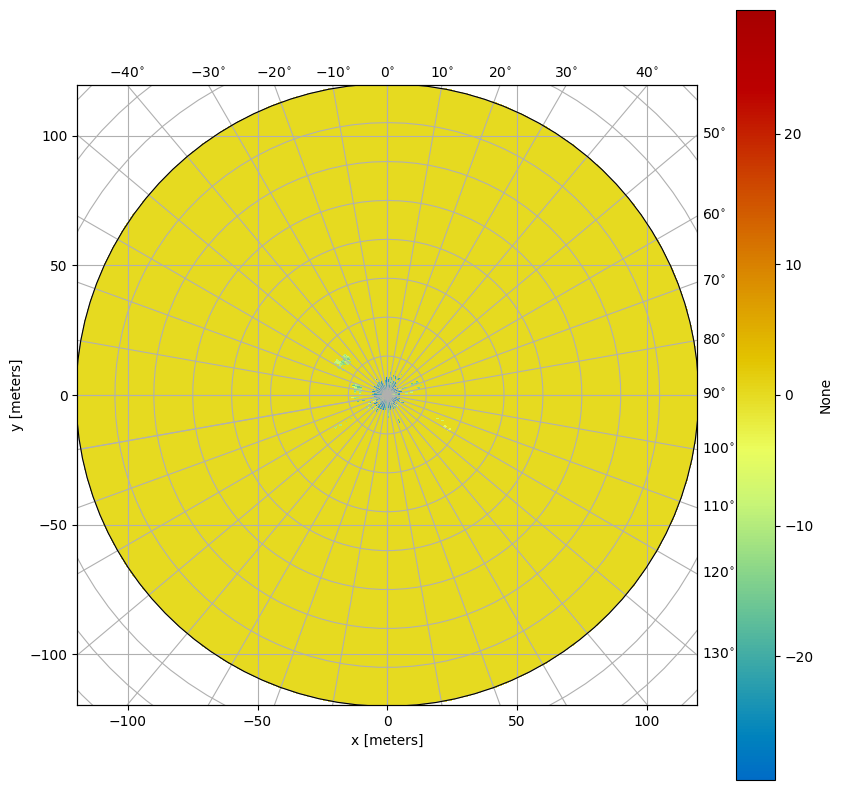

In [40]:
fig = plt.figure(figsize=(10, 10))
da = wrl.georef.create_xarray_dataarray(
    data["SCAN13"]["ZH"]["data"]
).wrl.georef.georeference()
im = da.wrl.vis.plot(fig=fig, crs="cg")

## Data Padding

In [9]:
for i in range(14):
    scan_key = f"SCAN{i}"
    print(f"{scan_key}: {data[scan_key]['ZH']['data'].shape}")

SCAN0: (361, 240)
SCAN1: (361, 240)
SCAN2: (360, 240)
SCAN3: (361, 240)
SCAN4: (361, 240)
SCAN5: (360, 200)
SCAN6: (360, 200)
SCAN7: (360, 200)
SCAN8: (360, 160)
SCAN9: (361, 160)
SCAN10: (360, 160)
SCAN11: (360, 160)
SCAN12: (361, 120)
SCAN13: (360, 120)


We need to pad the data to have a standard shape of 360, 240

In [ ]:
# pad the scans to a fixed size of (360, 240)
import numpy as np

TARGET_H, TARGET_W = 360, 240
processed_scans = []

for i in range(14):
    scan_key = f"SCAN{i}"
    data_array = data[scan_key]['ZH']['data']
    h, w = data_array.shape

    # Pad height
    if h > TARGET_H:
        data_array = data_array[:TARGET_H, :]
    elif h < TARGET_H:
        pad_bottom = TARGET_H - h
        data_array = np.pad(data_array, ((0, pad_bottom), (0, 0)), mode='constant', constant_values=0)

    # Pad width
    if w > TARGET_W:
        data_array = data_array[:, :TARGET_W]
    elif w < TARGET_W:
        pad_right = TARGET_W - w
        data_array = np.pad(data_array, ((0, 0), (0, pad_right)), mode='constant', constant_values=0)

    processed_scans.append(data_array)

# Stack to get shape (14, 360, 240)
input_array = np.stack(processed_scans)
print("Shape of standardized input array:", input_array.shape)

Shape of standardized input array: (14, 360, 240)


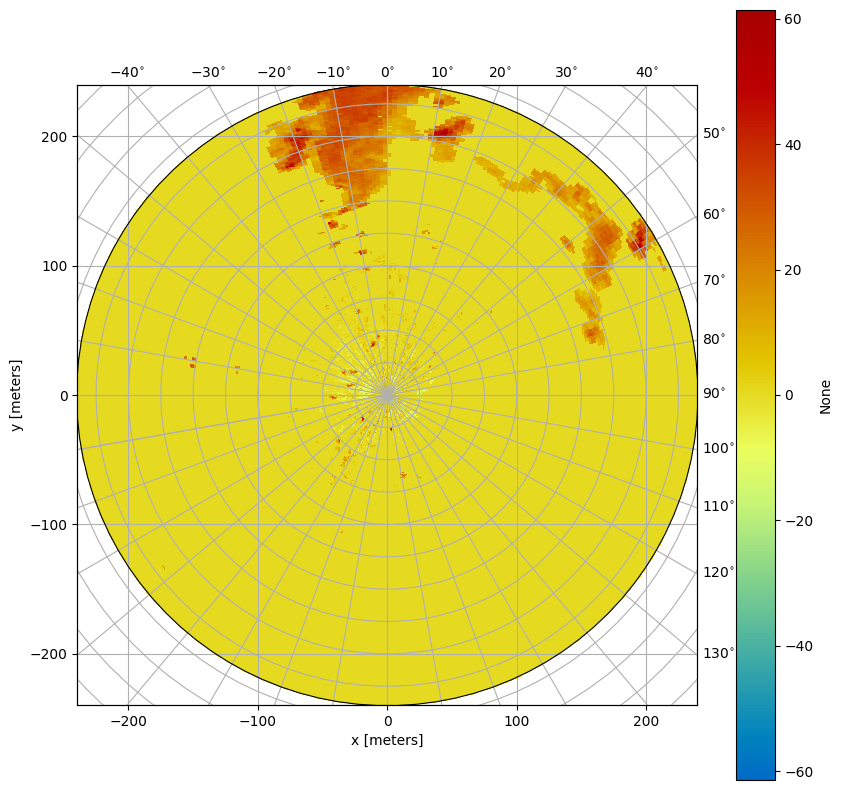

In [41]:
fig = plt.figure(figsize=(10, 10))
da = wrl.georef.create_xarray_dataarray(
    input_array[0]  # Use the first scan for plotting
).wrl.georef.georeference()
im = da.wrl.vis.plot(fig=fig, crs="cg")